In [ ]:
from google.colab import files
uploaded = files.upload()

TypeError: 'NoneType' object is not subscriptable

In [ ]:
import pandas as pd

# Load the CSV
df = pd.read_csv('chilli_rainfall_cleaned.csv')

# See the first 5 rows
df.head()

In [ ]:
# How many rows and columns?
print("Shape:", df.shape)

# Column names and data types
df.info()

# Any missing values?
df.isnull().sum()

# Quick statistical summary
df.describe()

In [ ]:
missing_rainfall = df[df['annual_rainfall_mm'].isnull()]
print(missing_rainfall)

In [ ]:
zero_rows = df[(df['Area(HA)'] == 0) | (df['Production(MT)'] == 0) | (df['Yield'] == 0)]
print(zero_rows)

In [ ]:
df['annual_rainfall_mm'] = df.groupby('State')['annual_rainfall_mm'].transform(
    lambda x: x.fillna(x.mean())
)

# Confirm no more missing values
df.isnull().sum()

In [ ]:
df['Year_num'] = df['Year'].str[:4].astype(int)
df[['Year', 'Year_num']].head()

In [ ]:
print("Duplicate rows:", df.duplicated().sum())

In [ ]:
df.to_csv('chilli_rainfall_cleaned.csv', index=False)

from google.colab import files
files.download('chilli_rainfall_cleaned.csv')

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving chilli_rainfall_final.csv to chilli_rainfall_final (1).csv


In [ ]:
import pandas as pd

df = pd.read_csv('chilli_rainfall_cleaned.csv')
df.head()

,State,Year,Area(HA),Production(MT),Yield,annual_rainfall_mm,Year_num
0,Andaman & Nicobar,2020-21,35,118,3.371,NaN,2020
1,Andaman & Nicobar,2021-22,98,340,3.469,NaN,2021
2,Andaman & Nicobar,2022-23,95,370,3.895,NaN,2022
3,Andaman & Nicobar,2023-24,63,167,2.651,NaN,2023
4,Andaman & Nicobar,2024-25,63,167,2.651,NaN,2024


In [ ]:
df_active = df[df['Production(MT)'] > 0].copy()

print("Total rows:", len(df))
print("Rows with actual chilli production:", len(df_active))

Total rows: 150
Rows with actual chilli production: 119


In [ ]:
top_states = df_active.groupby('State')['Production(MT)'].sum().sort_values(ascending=False)
print(top_states.head(10))

State
Andhra Pradesh    4919095
Telangana         3244054
Madhya Pradesh    1528063
Karnataka         1104341
Odisha             405537
Gujarat            155030
Tamil Nadu         135882
Uttar Pradesh      124224
Assam              106546
Punjab             105191
Name: Production(MT), dtype: int64


In [ ]:
rainfall_by_state = df_active.groupby('State')['annual_rainfall_mm'].mean().sort_values(ascending=False)
print(rainfall_by_state.head(5))   # wettest
print(rainfall_by_state.tail(5))   # driest

State
Arunachal Pradesh    2314.228
Assam                2118.926
West Bengal          1921.044
Tripura              1895.514
Mizoram              1813.934
Name: annual_rainfall_mm, dtype: float64
State
Uttar Pradesh        881.822
Punjab               635.306
Rajasthan            591.866
Jammu and Kashmir    492.716
Andaman & Nicobar        NaN
Name: annual_rainfall_mm, dtype: float64


In [ ]:
yearly_trend = df_active.groupby('Year_num')[['Yield', 'annual_rainfall_mm']].mean()
print(yearly_trend)

             Yield  annual_rainfall_mm
Year_num                              
2020      2.108739         1412.546818
2021      1.775250         1297.340870
2022      2.096500         1377.101304
2023      2.492333         1232.433913
2024      2.511917         1352.333043


In [ ]:
df_active['Yield'].describe()

,Yield
count,119.000000
mean,2.197689
std,1.860743
min,0.462000
25%,0.975000
50%,2.000000
75%,2.651500
max,12.713000


In [ ]:
outlier_row = df_active.sort_values('Yield', ascending=False).head(3)
print(outlier_row[['State','Year','Area(HA)','Production(MT)','Yield']])

         State     Year  Area(HA)  Production(MT)   Yield
79     Manipur  2024-25       300            3814  12.713
78     Manipur  2023-24       300            3814  12.713
120  Telangana  2020-21     89156          536541   6.018


In [ ]:
# Ranking by Area
top_by_area = df_active.groupby('State')['Area(HA)'].sum().sort_values(ascending=False)
print("Top 10 by Area:")
print(top_by_area.head(10))

# Ranking by Production
top_by_production = df_active.groupby('State')['Production(MT)'].sum().sort_values(ascending=False)
print("\nTop 10 by Production:")
print(top_by_production.head(10))

# Ranking by average Yield (efficiency, not just size)
top_by_yield = df_active.groupby('State')['Yield'].mean().sort_values(ascending=False)
print("\nTop 10 by average Yield (efficiency):")
print(top_by_yield.head(10))

Top 10 by Area:
State
Andhra Pradesh    1107047
Karnataka          715894
Telangana          671222
Madhya Pradesh     594036
Odisha             366443
Tamil Nadu         257478
Uttar Pradesh      142157
Assam              104211
Gujarat             71137
Mizoram             54294
Name: Area(HA), dtype: int64

Top 10 by Production:
State
Andhra Pradesh    4919095
Telangana         3244054
Madhya Pradesh    1528063
Karnataka         1104341
Odisha             405537
Gujarat            155030
Tamil Nadu         135882
Uttar Pradesh      124224
Assam              106546
Punjab             105191
Name: Production(MT), dtype: int64

Top 10 by average Yield (efficiency):
State
Manipur              6.6565
Telangana            4.9490
Andhra Pradesh       4.4682
Maharashtra          3.2398
Andaman & Nicobar    3.2074
Uttarakhand          3.1022
Tripura              2.7286
Arunachal Pradesh    2.5866
Madhya Pradesh       2.5722
Gujarat              2.1670
Name: Yield, dtype: float64


In [ ]:
correlation_overall = df_active['annual_rainfall_mm'].corr(df_active['Yield'])
print("Overall correlation (Rainfall vs Yield):", correlation_overall)

Overall correlation (Rainfall vs Yield): 0.03345646370733455


In [ ]:
cols_to_check = ['annual_rainfall_mm', 'Area(HA)', 'Production(MT)', 'Yield']
correlation_matrix = df_active[cols_to_check].corr()
print(correlation_matrix)

                    annual_rainfall_mm  Area(HA)  Production(MT)     Yield
annual_rainfall_mm            1.000000 -0.133689       -0.133099  0.033456
Area(HA)                     -0.133689  1.000000        0.877741  0.210690
Production(MT)               -0.133099  0.877741        1.000000  0.389839
Yield                         0.033456  0.210690        0.389839  1.000000


In [ ]:
state_correlations = df_active.groupby('State').apply(
    lambda x: x['annual_rainfall_mm'].corr(x['Yield']) if len(x) > 1 else None
).sort_values(ascending=False)

print(state_correlations)

State
Bihar                0.863202
Nagaland             0.843946
Jammu and Kashmir    0.728950
Telangana            0.694757
Tripura              0.544912
Maharashtra          0.407913
Rajasthan            0.311831
Uttarakhand          0.258105
Arunachal Pradesh    0.187671
Mizoram              0.158357
Gujarat              0.135791
Himachal Pradesh     0.003366
Manipur             -0.040245
Punjab              -0.085912
Tamil Nadu          -0.098177
Assam               -0.182029
Andhra Pradesh      -0.348428
Karnataka           -0.430344
Madhya Pradesh      -0.744697
Odisha              -0.768532
Chhattisgarh        -0.790887
West Bengal         -0.827055
Uttar Pradesh       -0.886548
Andaman & Nicobar         NaN
dtype: float64


/tmp/ipykernel_4138/672594328.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  state_correlations = df_active.groupby('State').apply(


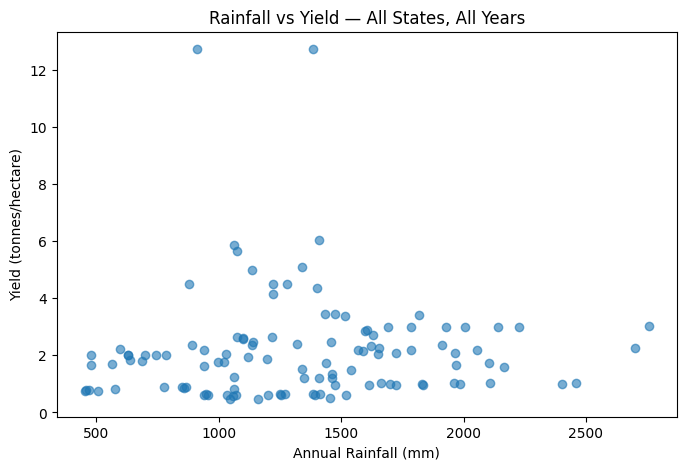

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(df_active['annual_rainfall_mm'], df_active['Yield'], alpha=0.6)
plt.xlabel('Annual Rainfall (mm)')
plt.ylabel('Yield (tonnes/hectare)')
plt.title('Rainfall vs Yield — All States, All Years')
plt.show()


/tmp/ipykernel_4138/848820556.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  state_correlations = df_active.groupby('State').apply(


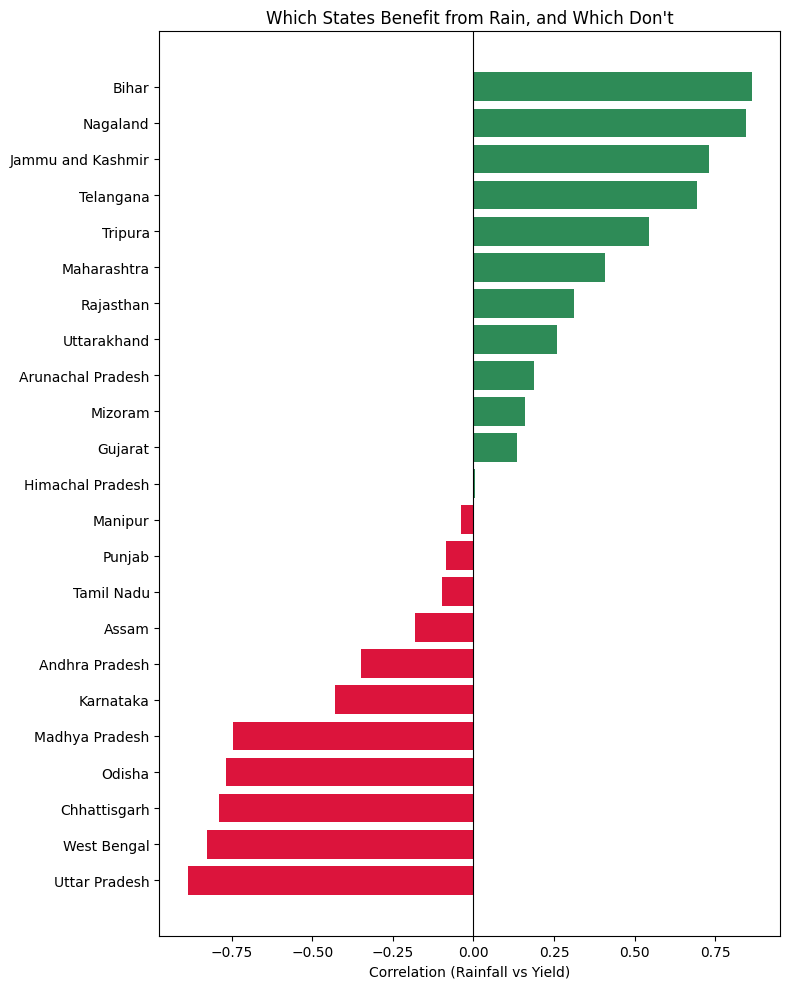

In [ ]:
import matplotlib.pyplot as plt

# Recalculate and drop the NaN (Andaman & Nicobar) since it can't be plotted
state_correlations = df_active.groupby('State').apply(
    lambda x: x['annual_rainfall_mm'].corr(x['Yield']) if len(x) > 1 else None
).dropna().sort_values()

plt.figure(figsize=(8, 10))
colors = ['crimson' if v < 0 else 'seagreen' for v in state_correlations]
plt.barh(state_correlations.index, state_correlations.values, color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Correlation (Rainfall vs Yield)')
plt.title('Which States Benefit from Rain, and Which Don\'t')
plt.tight_layout()
plt.show()

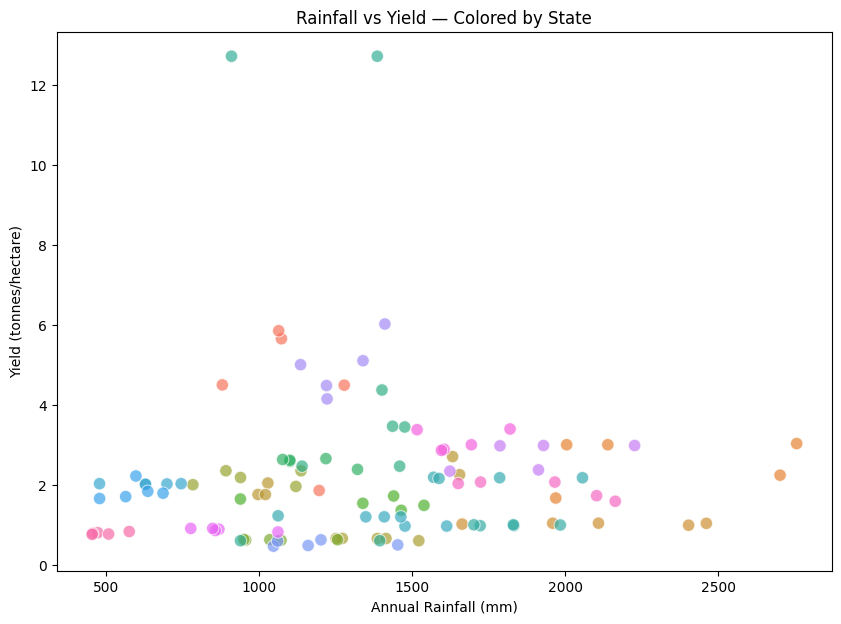

In [ ]:
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_active, x='annual_rainfall_mm', y='Yield', hue='State', legend=False, alpha=0.7, s=80)
plt.xlabel('Annual Rainfall (mm)')
plt.ylabel('Yield (tonnes/hectare)')
plt.title('Rainfall vs Yield — Colored by State')
plt.show()

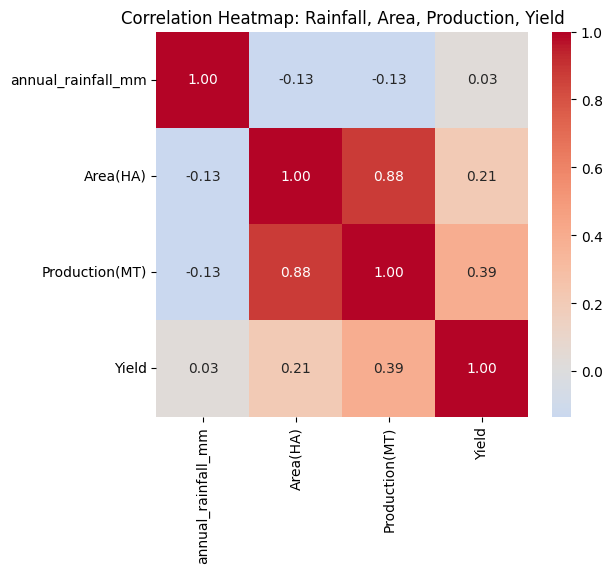

In [ ]:
plt.figure(figsize=(6, 5))
cols_to_check = ['annual_rainfall_mm', 'Area(HA)', 'Production(MT)', 'Yield']
sns.heatmap(df_active[cols_to_check].corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Heatmap: Rainfall, Area, Production, Yield')
plt.show()

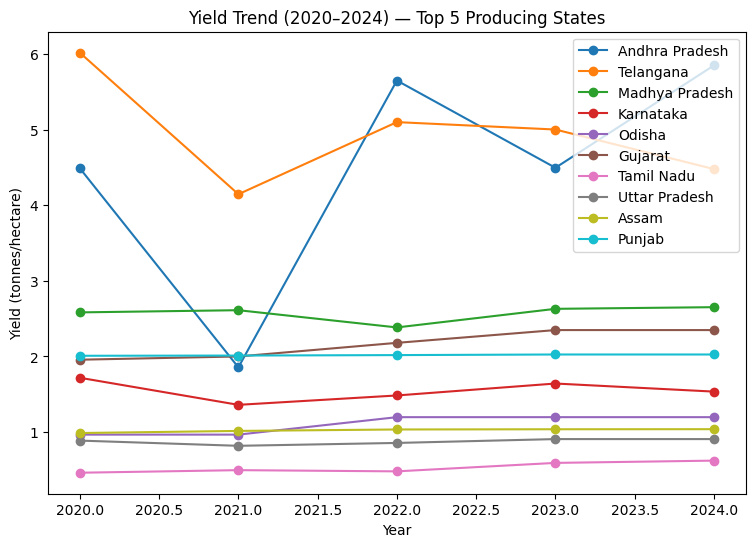

In [ ]:
top5_states = df_active.groupby('State')['Production(MT)'].sum().sort_values(ascending=False).head(10).index

plt.figure(figsize=(9, 6))
for state in top5_states:
    subset = df_active[df_active['State'] == state].sort_values('Year_num')
    plt.plot(subset['Year_num'], subset['Yield'], marker='o', label=state)

plt.xlabel('Year')
plt.ylabel('Yield (tonnes/hectare)')
plt.title('Yield Trend (2020–2024) — Top 5 Producing States')
plt.legend()
plt.show()

In [ ]:
import os
os.makedirs('charts', exist_ok=True)

# Re-run each plot but save instead of just show, e.g.:
plt.savefig('charts/yield_trend_top5.png', dpi=150, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

In [ ]:
from sklearn.model_selection import train_test_split

# Features (inputs) and target (what we're predicting)
features = ['Area(HA)', 'annual_rainfall_mm']
target = 'Yield'

X = df_active[features]
y = df_active[target]

# Split into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 95
Testing rows: 24


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

print("Linear Regression R²:", r2_score(y_test, y_pred_lr))
print("Linear Regression RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))

In [ ]:
df[df['State'] == 'Andaman & Nicobar'][['State', 'Year', 'annual_rainfall_mm']]

,State,Year,annual_rainfall_mm
0,Andaman & Nicobar,2020-21,NaN
1,Andaman & Nicobar,2021-22,NaN
2,Andaman & Nicobar,2022-23,NaN
3,Andaman & Nicobar,2023-24,NaN
4,Andaman & Nicobar,2024-25,NaN


In [ ]:
# Step 1: fill with state's own average (already done, but re-run safely)
df['annual_rainfall_mm'] = df.groupby('State')['annual_rainfall_mm'].transform(
    lambda x: x.fillna(x.mean())
)

# Step 2: any states that were fully NaN (like Andaman & Nicobar) still remain --
# fill those remaining gaps with the overall national average
df['annual_rainfall_mm'] = df['annual_rainfall_mm'].fillna(df['annual_rainfall_mm'].mean())

# Confirm no NaNs remain anywhere
print(df.isnull().sum())

State                 0
Year                  0
Area(HA)              0
Production(MT)        0
Yield                 0
annual_rainfall_mm    0
Year_num              0
dtype: int64


In [ ]:
df_active = df[df['Production(MT)'] > 0].copy()

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

print("Linear Regression R²:", r2_score(y_test, y_pred_lr))
print("Linear Regression RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))

ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest R²:", r2_score(y_test, y_pred_rf))
print("Random Forest RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))

Random Forest R²: 0.045198653244278075
Random Forest RMSE: 1.1932012532154832


In [ ]:
importance = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=False)
print(importance)

NameError: name 'rf_model' is not defined

In [ ]:
df.to_csv('chilli_rainfall_final.csv', index=False)

from google.colab import files
files.download('chilli_rainfall_final.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# New Section

In [ ]:
state_correlations = df_active.groupby('State').apply(
    lambda x: x['annual_rainfall_mm'].corr(x['Yield']) if len(x) > 1 else None
).reset_index()

state_correlations.columns = ['State', 'Rainfall_Yield_Correlation']
state_correlations = state_correlations.dropna()

state_correlations.to_csv('state_correlations.csv', index=False)

from google.colab import files
files.download('state_correlations.csv')

/usr/local/lib/python3.13/dist-packages/numpy/lib/_function_base_impl.py:2999: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.13/dist-packages/numpy/lib/_function_base_impl.py:3000: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/tmp/ipykernel_4138/3102633200.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  state_correlations = df_active.groupby('State').apply(


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>